In [1]:
import sys
sys.path.append('../')
from utils_models import *

In [2]:

with open('../pickles/detection_sensitivity.pkl', 'rb') as file:
    results = pickle.load(file)



In [4]:
Er_list = np.linspace(7.19094727-0.02,7.19094727+0.02,100)

In [3]:
max_ql = 15
max_ol = 30
system = FluxoniumOscillatorSystem(
            EJ = 2.7,
            EC = 0.6,
            EL = 0.13,
            Er = 7.19094727,
            g_strength = 0.21,
            qubit_level = max_ql,
            osc_level = max_ol,
            products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(35) ],
            computaional_states = '1,2',
            )

In [21]:
len(results)

300

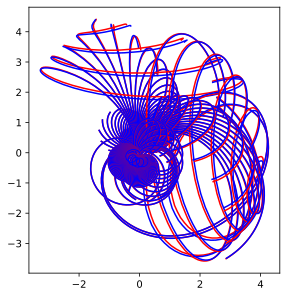

In [65]:

tot_time = len(results[0].times)
tlist = np.linspace(0, tot_time, tot_time)

# prefix = rf'$\kappa = 10^{{-3}}$'
colors = ['red','blue','green']



for j in range(0, 600, 6):
    # Ensure the slice does not exceed list bounds
    results_group = results[j:j+6]
    first_dominant_freq =find_dominant_frequency(results_group[0].expect[0],tlist)
    for i, result in enumerate([results_group[0], results_group[1] ]):
        alpha = result.expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
        plt.plot(alpha.imag,alpha.real,color=colors[i],label =  rf'$\left|{i}\right>$')
# plt.legend()
plt.gca().set_aspect('equal', 'box')

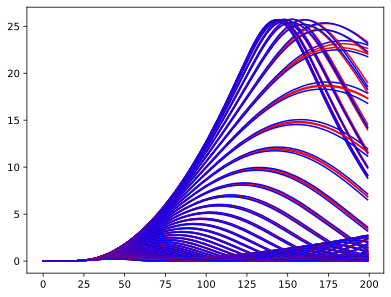

In [62]:

tot_time = len(results[0].times)
tlist = np.linspace(0, tot_time, tot_time)

# prefix = rf'$\kappa = 10^{{-3}}$'
colors = ['red','blue','green']



for j in range(0, 600, 6):
    # Ensure the slice does not exceed list bounds
    results_group = results[j:j+6]
    for i, result in enumerate([results_group[0], results_group[1] ]):
        plt.plot(result.expect[1],color=colors[i],label =  rf'$\left|{i}\right>$')
# plt.legend()


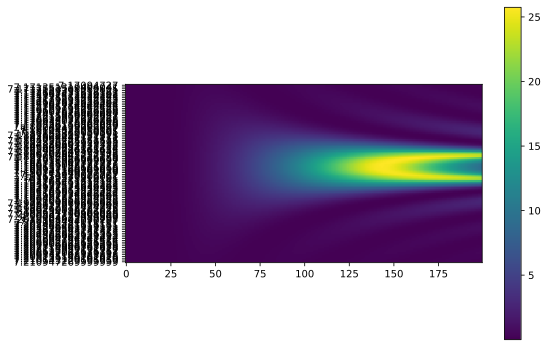

In [64]:
list_of_pn = []
for j in range(0, 600, 6):
    results_group = results[j:j+2]
    list_of_pn.append(np.array(results_group[0].expect[1])/2+np.array(results_group[1].expect[1])/2)
list_of_pn = np.array(list_of_pn)
import numpy as np
import matplotlib.pyplot as plt


plt.imshow(list_of_pn, cmap='viridis', interpolation='nearest')
plt.gcf().set_size_inches(8, 6)  
plt.colorbar() 
plt.yticks(ticks = list(range(100)),labels=Er_list)
plt.show()




In [6]:
num_time_steps = len(results[0].times)
tlist = results[0].times
slice_interval = 1
new_tlist = tlist[::slice_interval]
num_time_steps = len(new_tlist)

zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [
                zero,
                one,
                (zero +  one).unit(),
                (zero -  one).unit(),
                (zero + 1j * one).unit(),
                (zero - 1j * one).unit(),
                ]


def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,dm_ideal in zip(dms,states_ideal):
        new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(new_dm, dm_ideal))
        # fid.append(qutip.fidelity(dm, gate*dm_ideal))
    return 1-sum(fid)/len(fid)


from scipy.optimize import minimize



infidelity = [[] for _ in range(int( len(results)/ 6))] 
phase_lump = [[] for _ in range( int(len(results)/ 6))] 

for i in tqdm(range(0, 600, 6)):
    # Ensure the slice does not exceed list bounds
    results_group = results[i:i+6]

    for idx in range(num_time_steps):
        dms = [result.states_dressed_to_2_level_dm[idx*slice_interval] for result in results_group]
        def objective_function(phase):
            return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
        initial_phase = [0.0]
        bounds = [(0, 2 * 3.141592653589793)]
        opt_result = minimize(objective_function, initial_phase,method="COBYLA")
        infidelity[int(i/6)].append(opt_result.fun)
        phase_lump[int(i/6)].append(opt_result.x[0])




100%|██████████| 100/100 [14:45<00:00,  8.85s/it]


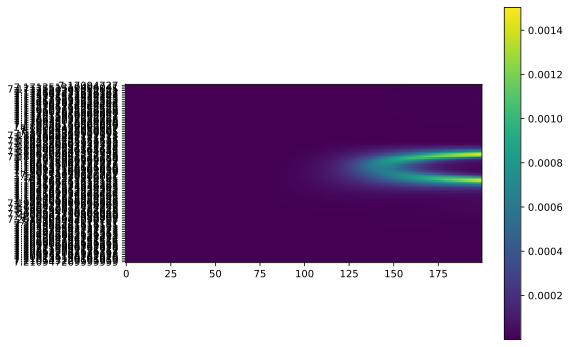

In [7]:
import numpy as np
import matplotlib.pyplot as plt

infidelity = np.array(infidelity)
plt.imshow(infidelity, cmap='viridis', interpolation='nearest')
plt.gcf().set_size_inches(8, 6)  
plt.colorbar() 
plt.yticks(ticks = list(range(100)),labels=np.linspace(7.19094727-0.02,7.19094727+0.02,100))
plt.show()




Text(0.5, 0, 't (ns)')

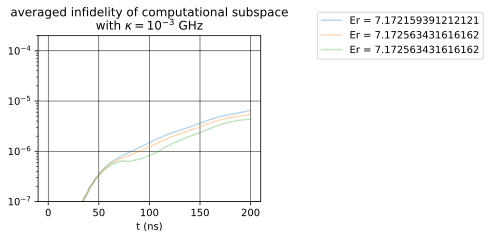

In [8]:

plt.figure(figsize = (4,3))
for i in range(23,26):
    plt.plot(new_tlist,infidelity[i],label = f'Er = {Er_list[int(i/6)]}',alpha = 0.3)

plt.grid(which='major', linestyle='-', linewidth='0.5', color='black')
# plt.minorticks_on()
# plt.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')

plt.legend(loc='center right', bbox_to_anchor=(2, 1), borderaxespad=0.)

plt.yscale('log')
plt.ylim(1e-7,2e-4)
plt.title(rf"""averaged infidelity of computational subspace
with $\kappa = 10^{{-3}}$ GHz""")
plt.xlabel("t (ns)")